In [3]:
#!/Library/Frameworks/Python.framework/Versions/3.11/bin/pip3 install hipopy
import hipopy.hipopy as hp, numpy as np, matplotlib.pyplot as plt,awkward as ak

import mplhep as hep
hep.style.use("CMS")

1.929

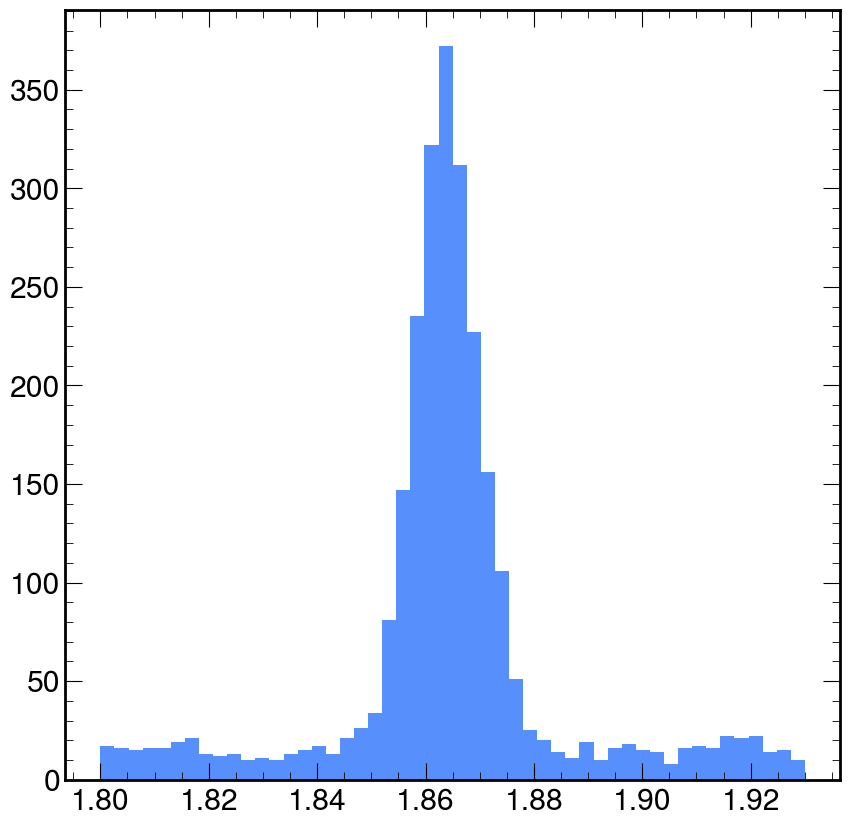

In [4]:
signal=np.random.normal(1.864,.006,1900)
bkgd=np.random.uniform(1.8,1.93,1900*4//10)
plt.hist(np.concatenate((signal, bkgd)), bins=50, range=(1.8,1.93))
1.864+5*.013

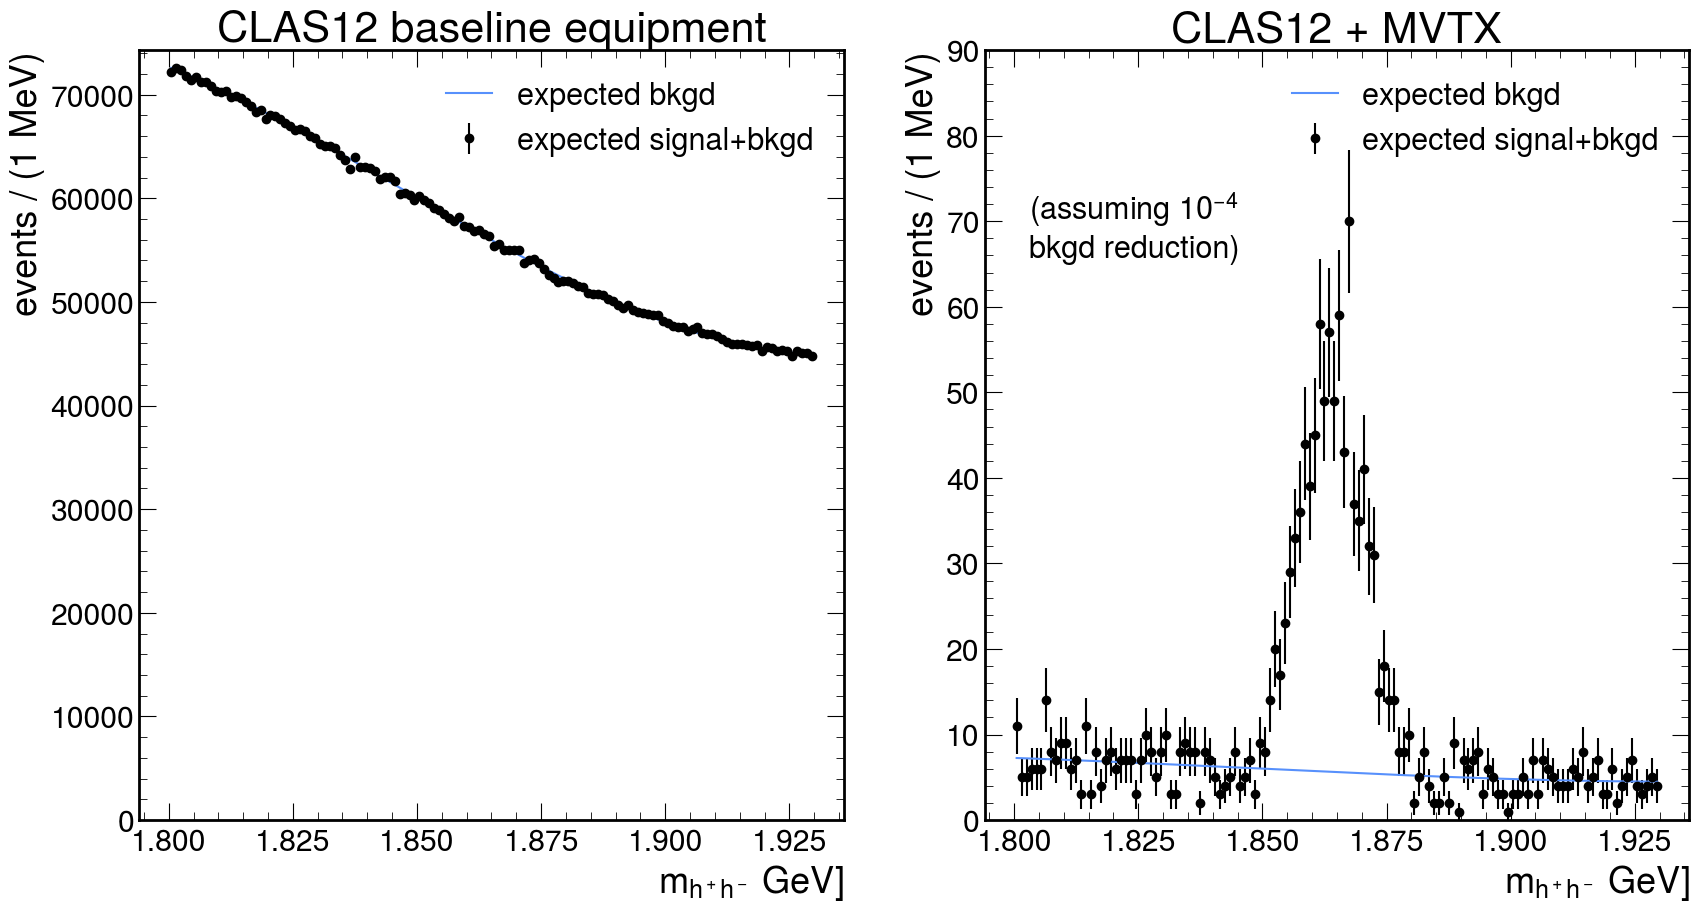

In [8]:
fig, axs=plt.subplots(1,2, figsize=(20,10))
for i in range(2):
    plt.sca(axs[i])
    if i == 0:
        reduction_factor=1
        plt.title("CLAS12 baseline equipment")
    if i == 1:
        plt.title("CLAS12 + MVTX")
        reduction_factor=0.0001
#reduction_factor=(.011*.001+.00003+.00004)

    bkgd_poly=np.array([ 13053.86613199, -72318.35596808, 133251.82584625, -81594.40299113])
    bkgd_scale=7.4e6/7896*reduction_factor
    
    signal=np.random.normal(1.864,.0060,504+307)
    y,x=np.histogram(signal, bins=130, range=(1.8,1.93))
    x=(x[1:]+x[:-1])/2
    
    bsmooth=np.polyval(bkgd_poly*bkgd_scale, x)
    
    b=np.random.poisson(bsmooth, len(x))
    plt.errorbar(x, y+b, np.sqrt(y+b), marker='o', color='k', ls='', label='expected signal+bkgd')
    plt.plot(x,bsmooth, label='expected bkgd')
    plt.legend(fontsize=22)
    if i == 1:
        plt.text(1.803, plt.gca().get_ylim()[1]*.8, "(assuming $10^{-4}$\nbkgd reduction)", fontsize=22)
    plt.xlabel("$m_{h^+h^-}$ GeV]")
    plt.ylabel("events / (1 MeV)")
    plt.ylim(0)
axs[1].set_ylim(0, 90)
plt.savefig('images/background_reduction.pdf')


In [43]:
help(np.random.poisson)

Help on method poisson in module numpy.random:

poisson(lam=1.0, size=None) method of numpy.random.mtrand.RandomState instance
    poisson(lam=1.0, size=None)
    
    Draw samples from a Poisson distribution.
    
    The Poisson distribution is the limit of the binomial distribution
    for large N.
    
    .. note::
        New code should use the `~numpy.random.Generator.poisson`
        method of a `~numpy.random.Generator` instance instead;
        please see the :ref:`random-quick-start`.
    
    Parameters
    ----------
    lam : float or array_like of floats
        Expected number of events occurring in a fixed-time interval,
        must be >= 0. A sequence must be broadcastable over the requested
        size.
    size : int or tuple of ints, optional
        Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
        ``m * n * k`` samples are drawn.  If size is ``None`` (default),
        a single value is returned if ``lam`` is a scalar. Otherwise,
        

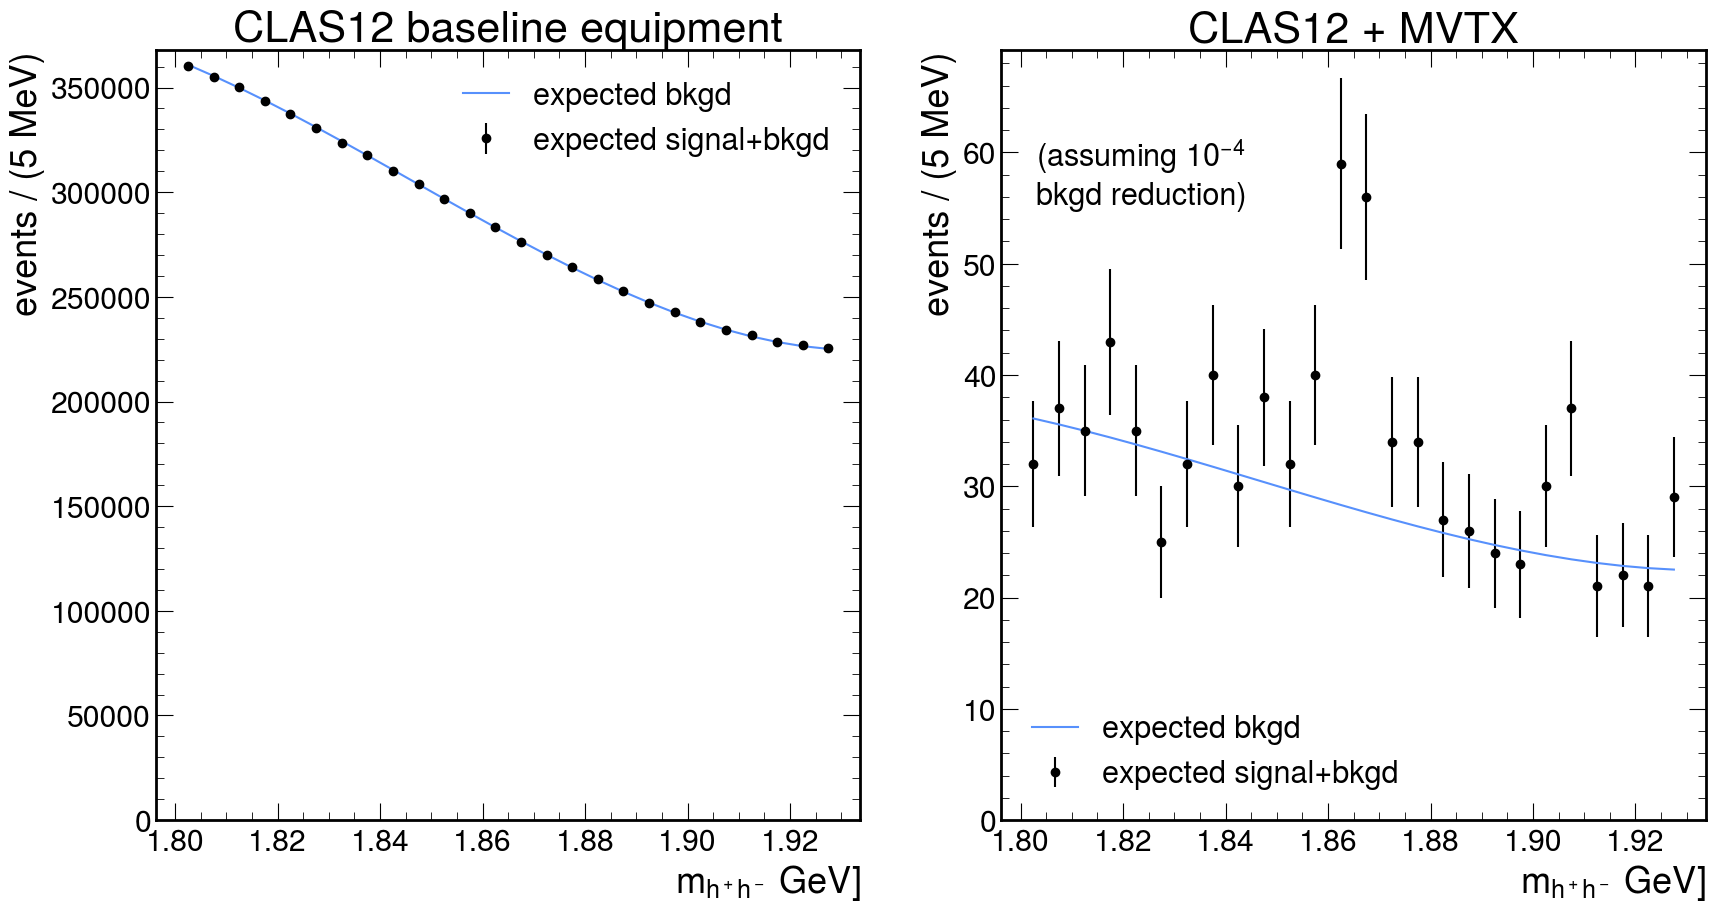

In [13]:
fig, axs=plt.subplots(1,2, figsize=(20,10))
for i in range(2):
    plt.sca(axs[i])
    if i == 0:
        reduction_factor=1
        plt.title("CLAS12 baseline equipment")
    if i == 1:
        plt.title("CLAS12 + MVTX")
        reduction_factor=0.0001

    bkgd_poly=np.array([ 13053.86613199, -72318.35596808, 133251.82584625, -81594.40299113])
    bkgd_scale=7.4e6/7896*reduction_factor
    
    signal=np.random.normal(1.864,.006,800//10)
    y,x=np.histogram(signal, bins=130//5, range=(1.8,1.93))
    x=(x[1:]+x[:-1])/2
    
    bsmooth=np.polyval(bkgd_poly*bkgd_scale*5, x)
    
    b=np.random.poisson(bsmooth, len(x))
    plt.errorbar(x, y+b, np.sqrt(y+b), marker='o', color='k', ls='', label='expected signal+bkgd')
    plt.plot(x,bsmooth, label='expected bkgd')
    plt.legend(fontsize=22)
    if i == 1:
        plt.text(1.803, plt.gca().get_ylim()[1]*.8, "(assuming $10^{-4}$\nbkgd reduction)", fontsize=22)
    plt.xlabel("$m_{h^+h^-}$ GeV]")
    plt.ylabel("events / (5 MeV)")
    plt.ylim(0)
#axs[1].set_ylim(0, 100)
plt.savefig('images/background_reduction_low_xs.pdf')

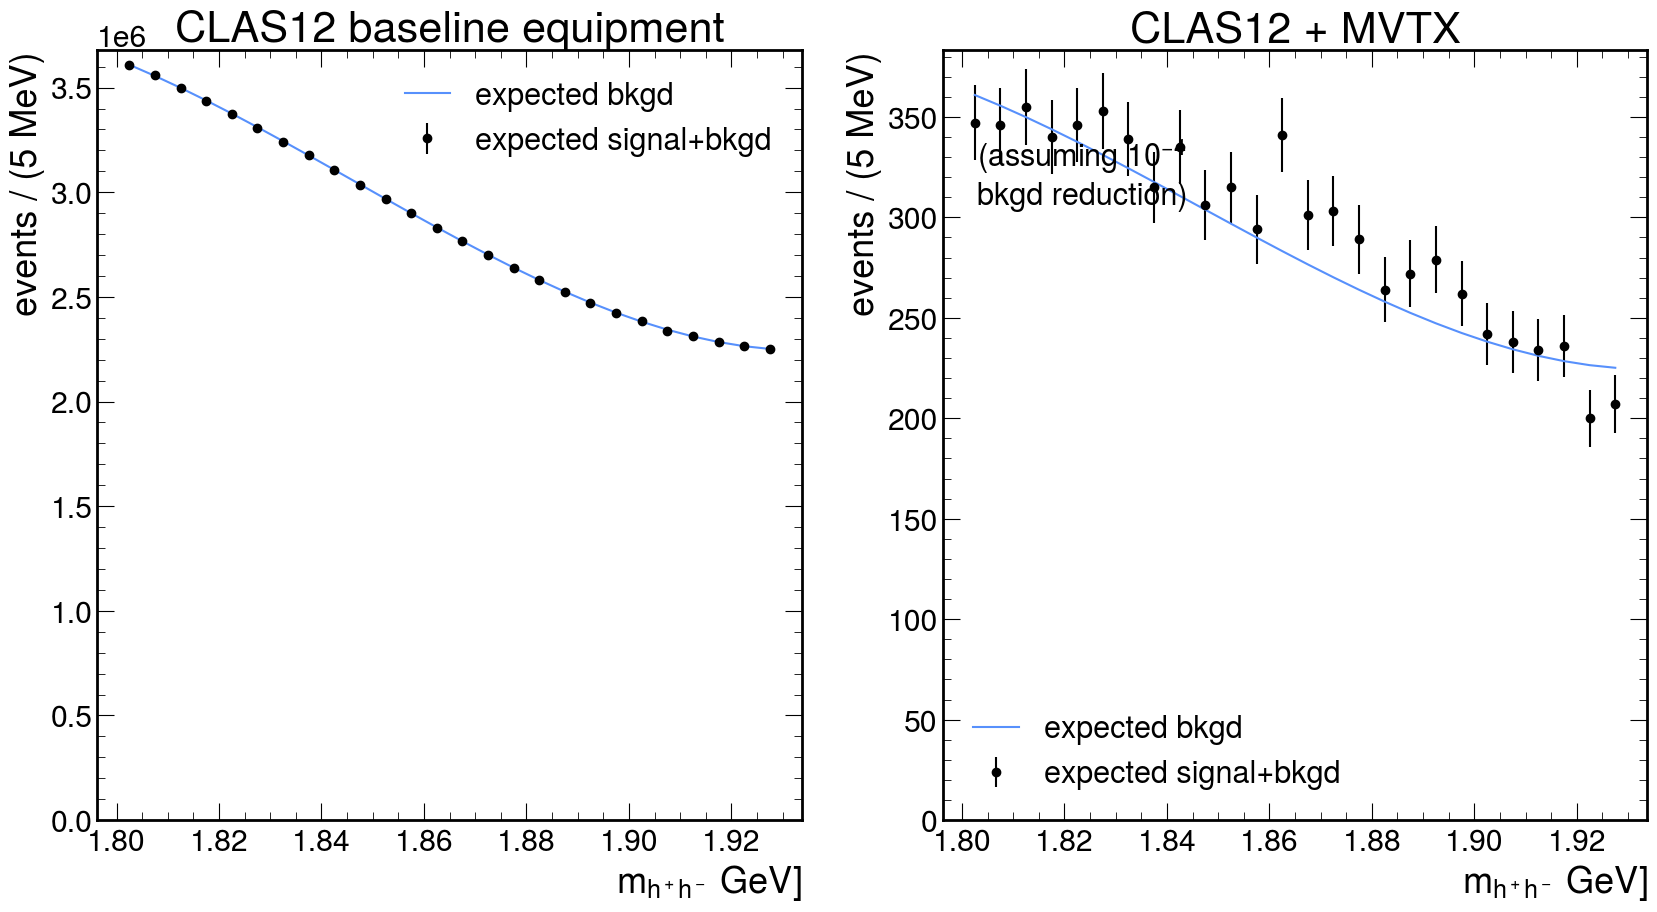

In [13]:
fig, axs=plt.subplots(1,2, figsize=(20,10))
for i in range(2):
    plt.sca(axs[i])
    if i == 0:
        reduction_factor=1
        plt.title("CLAS12 baseline equipment")
    if i == 1:
        plt.title("CLAS12 + MVTX")
        reduction_factor=0.0001

    bkgd_poly=np.array([ 13053.86613199, -72318.35596808, 133251.82584625, -81594.40299113])
    bkgd_scale=7.4e6/7896*reduction_factor*10
    
    signal=np.random.normal(1.864,.0089,1400//100*10)
    y,x=np.histogram(signal, bins=130//5, range=(1.8,1.93))
    x=(x[1:]+x[:-1])/2
    
    bsmooth=np.polyval(bkgd_poly*bkgd_scale*5, x)
    
    b=np.random.poisson(bsmooth, len(x))
    plt.errorbar(x, y+b, np.sqrt(y+b), marker='o', color='k', ls='', label='expected signal+bkgd')
    plt.plot(x,bsmooth, label='expected bkgd')
    plt.legend(fontsize=22)
    if i == 1:
        plt.text(1.803, plt.gca().get_ylim()[1]*.8, "(assuming $10^{-4}$\nbkgd reduction)", fontsize=22)
    plt.xlabel("$m_{h^+h^-}$ GeV]")
    plt.ylabel("events / (5 MeV)")
    plt.ylim(0)
#axs[1].set_ylim(0, 100)
plt.savefig('images/background_reduction_super_low_xs.pdf')